In [18]:
import pandas as pd
import numpy as np
from scipy import stats 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency


In [2]:
# Direct download link to a CSV file stored on Google Drive
url = 'https://drive.google.com/uc?export=download&id=1eR3NZtwIC6ECN3vhtrynqmx8okG0twA7'
chess = pd.read_csv(url)

In [3]:
# Calculate the absolute difference between white and black player ratings
chess['rating_diff'] = abs(chess['white_rating'] - chess['black_rating'])

In [4]:
# Generate descriptive statistics for the rating difference column
# This includes count, mean, std, min, max, and quartiles
descripe = chess['rating_diff'].describe()
skew =chess['rating_diff'].skew()
iqr = chess['rating_diff'].quantile(0.75) - chess['rating_diff'].quantile(0.25)
print('discribeing the statiscs :' , descripe , '\nthe skew is ' ,skew , '\nthe iqr ' , iqr)


discribeing the statiscs : count    20058.000000
mean       173.091435
std        179.214854
min          0.000000
25%         45.000000
50%        115.000000
75%        241.000000
max       1605.000000
Name: rating_diff, dtype: float64 
the skew is  1.9486762216717806 
the iqr  196.0


In [5]:
# Generate descriptive statistics for the 'turns' column (game length)
# This includes count, mean, standard deviation, min, max, and quartiles
descripe_rating = chess['turns'].describe()
skew_rating =chess['turns'].skew()
iqr_rating = chess['turns'].quantile(0.75) - chess['turns'].quantile(0.25)
print('discribeing the statiscs :' , descripe_rating , '\nthe skew is ' ,skew_rating , '\nthe iqr ' , iqr_rating)


discribeing the statiscs : count    20058.000000
mean        60.465999
std         33.570585
min          1.000000
25%         37.000000
50%         55.000000
75%         79.000000
max        349.000000
Name: turns, dtype: float64 
the skew is  0.897283771438351 
the iqr  42.0


In [6]:
# Perform Shapiro-Wilk test for normality on a sample of 'rating_diff'
# A random sample of 1000 rows is used for computational efficiency
stat_diff, p_diff = stats.shapiro(chess['rating_diff'].sample(1000, random_state=42))
stat_rated, p_rated = stats.shapiro(chess['turns'].sample(1000, random_state=42))
print(f"Shapiro-Wilk p = {p_diff:.6f}")
print(f"Shapiro-Wilk p = {p_rated:.6f}")


Shapiro-Wilk p = 0.000000
Shapiro-Wilk p = 0.000000


In [7]:
# Apply log transformation (log(1 + x)) to reduce skewness and handle large values

chess['turns_log'] = np.log1p(chess['turns'])
chess['rating_diff_log'] = np.log1p(chess['rating_diff'])


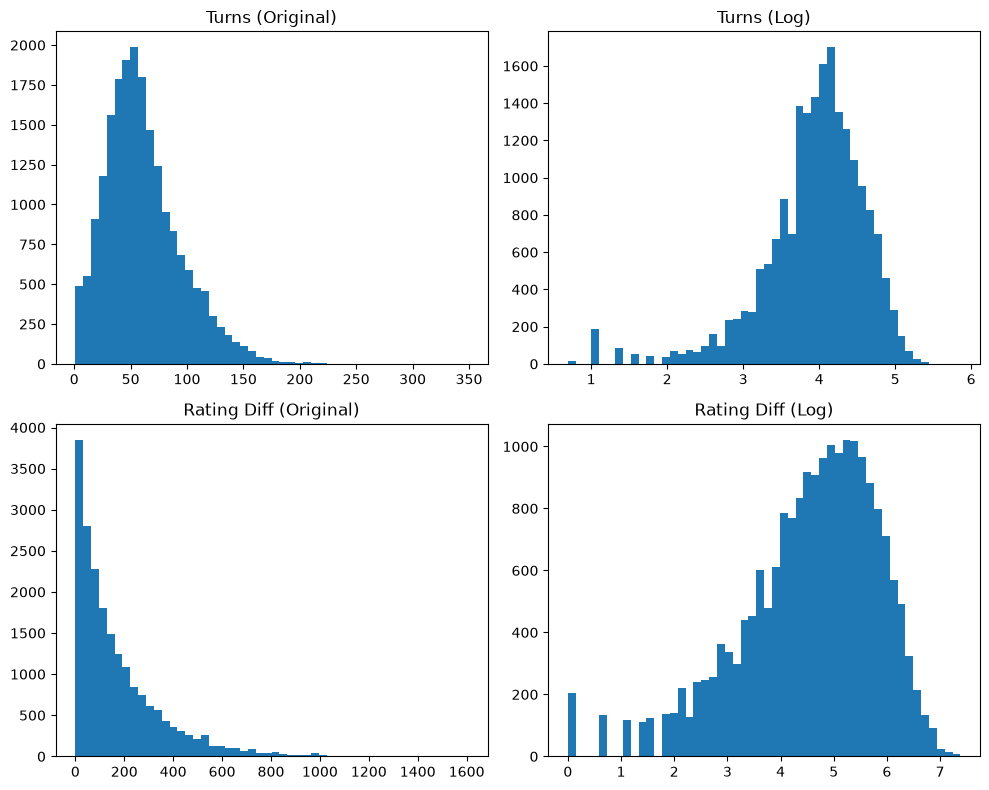

In [8]:
# Create a 2x2 grid of subplots to compare original vs log-transformed distributions
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

# turns original
ax[0,0].hist(chess['turns'], bins=50)
ax[0,0].set_title("Turns (Original)")

# turns log
ax[0,1].hist(chess['turns_log'], bins=50)
ax[0,1].set_title("Turns (Log)")

# rating_diff original
ax[1,0].hist(chess['rating_diff'], bins=50)
ax[1,0].set_title("Rating Diff (Original)")

# rating_diff log
ax[1,1].hist(chess['rating_diff_log'], bins=50)
ax[1,1].set_title("Rating Diff (Log)")

plt.tight_layout()

# 💾 save image
plt.savefig("outputImages/distribution_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Compare skewness before and after log transformation
# Skewness shows how asymmetric the distribution is

print("Turns skew (original):", chess['turns'].skew())
print("Turns skew (log):", chess['turns_log'].skew())

print("Rating_diff skew (original):", chess['rating_diff'].skew())
print("Rating_diff skew (log):", chess['rating_diff_log'].skew())

Turns skew (original): 0.897283771438351
Turns skew (log): -1.3708338858711593
Rating_diff skew (original): 1.9486762216717806
Rating_diff skew (log): -0.9005824660211456


In [10]:
who_url = 'https://github.com/Priyankkoul/Life-Expectancy-WHO---Data-Analytics/blob/master/DATASET.csv?raw=true'
who = pd.read_csv(who_url)

In [13]:
who.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='str')

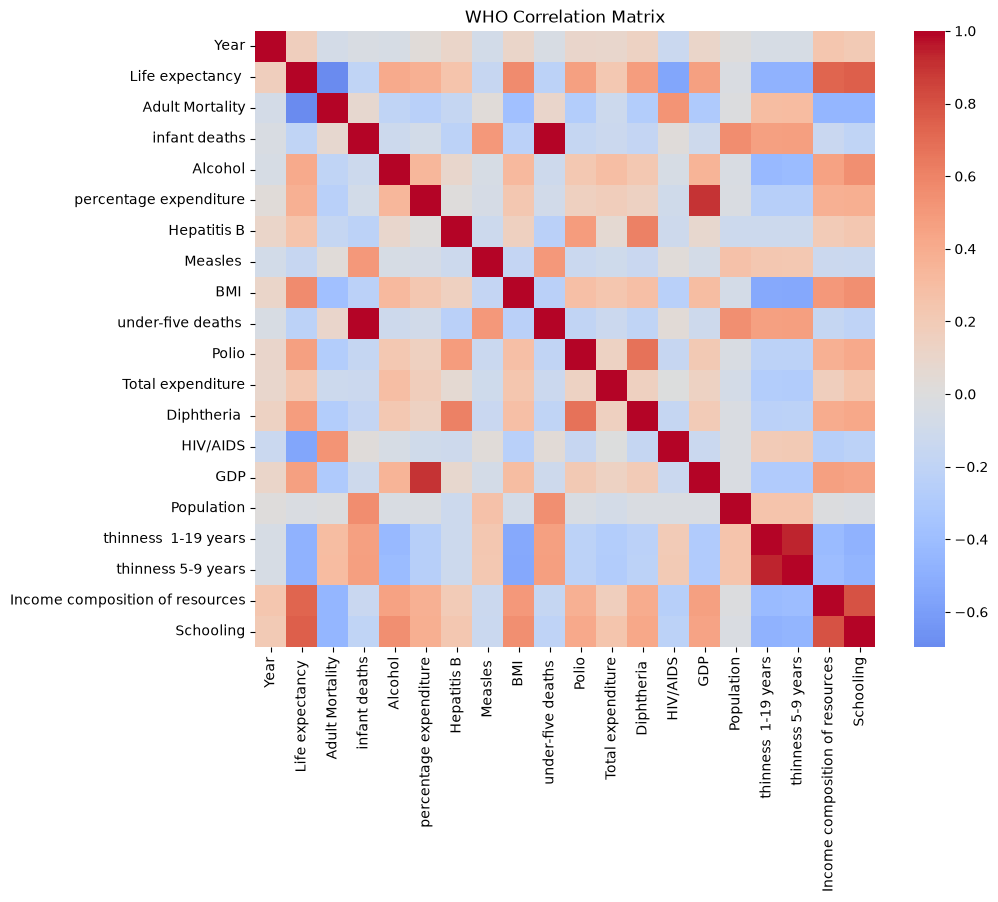

In [11]:
# Select only numeric columns from the WHO dataset
who_num = who.select_dtypes(include=['number'])

# Compute correlation matrix between all numeric variables
corr = who_num.corr()

# Create a figure with a defined size
plt.figure(figsize=(10, 8))

# Plot correlation matrix as a heatmap
sns.heatmap(corr, cmap='coolwarm', center=0)

# Add a title to the plot
plt.title("WHO Correlation Matrix")

# Save the figure to a file with high resolution
plt.savefig("outputImages/who_correlation_matrix.png", dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

In [12]:
# Extract correlation values with Life expectancy column
corr_life = corr['Life expectancy '].sort_values(ascending=False)

# Print the strongest positive correlations (top 5)
print("Top Positive Correlations:")
print(corr_life.head(5))

# Print the strongest negative correlations (bottom 5)
print("\nTop Negative Correlations:")
print(corr_life.tail(5))

Top Positive Correlations:
Life expectancy                    1.000000
Schooling                          0.751975
Income composition of resources    0.724776
 BMI                               0.567694
Diphtheria                         0.479495
Name: Life expectancy , dtype: float64

Top Negative Correlations:
under-five deaths       -0.222529
 thinness 5-9 years     -0.471584
 thinness  1-19 years   -0.477183
 HIV/AIDS               -0.556556
Adult Mortality         -0.696359
Name: Life expectancy , dtype: float64


In [ ]:
# Create a binary column indicating whether White player won the game
# True → 1, False → 0
chess['white_win'] = (chess['winner'] == 'White').astype(int)

# Group rating differences into categorical bins:
# Low: 0–100 rating difference
# Medium: 100–300 rating difference
# High: 300+ rating difference (up to max value in dataset)
chess['rating_group'] = pd.cut(
    chess['rating_diff'],
    bins=[0, 100, 300, chess['rating_diff'].max()],
    labels=['Low', 'Medium', 'High']
)

In [ ]:
# Create a contingency table (cross-tabulation) between rating group and white win outcome
# This shows how many games fall into each combination:
# rows → rating difference groups (Low, Medium, High)
# columns → white_win (0 = White lost, 1 = White won)
table = pd.crosstab(
    chess['rating_group'] , 
    chess['white_win'] , 
)

white_win,0,1
rating_group,,
Low,4550,4409
Medium,3610,3635
High,1789,1862


In [ ]:
# Perform Chi-square test of independence
# Tests whether there is a relationship between rating group and white win outcome
chi2, p, dof, expected = chi2_contingency(table)

# Print test statistics
print(f"Chi-square = {chi2:.3f}")
print(f"p-value = {p:.6f}")

Chi-square = 3.672
p-value = 0.159465


In [ ]:
# Compute total number of observations in the contingency table
n = table.sum().sum()

# Compute Cramér's V effect size for Chi-square test
# Measures strength of association (0 = no association, 1 = strong association)
cramers_v = np.sqrt(
    chi2 / (n * (min(table.shape)-1))
)

# Print result
print(f"Cramer's V = {cramers_v:.3f}")

Cramer's V = 0.014
